In [ ]:
""" import pandas as pd
import folium


df = pd.read_csv("mv.csv")
df = df.dropna(subset=["lat", "lng", "population"])

m = folium.Map(location=[14.5958, 120.9772], zoom_start=7
               , tiles="cartodb positron")

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=max(row["population"]**0.5 / 100, 2),  
        color="crimson",
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['city']}: {int(row['population'])}"
    ).add_to(m)

m.save("maldives_population_bubbles.html") """

In [ ]:
""" 

ph_df = pd.read_csv("ph.csv")
ph_df["city_clean"] = ph_df["city"].str.strip().str.upper()

pop_xlsx = pd.read_excel("1_2020%20CPH_Urban%20Population_PR%20Statistical%20Tables_RML_063022_ONS%20%282%29.xlsx", sheet_name="Table A", skiprows=7)

pop_xlsx.columns = [
    "location", "pop_2020", "pop_2015", "urban_pop_2020", "urban_pop_2015",
    "unused1", "percent_urban_2020", "percent_urban_2015", "unused2"
]
pop_df = pop_xlsx[["location", "pop_2020"]].dropna()
pop_df["location_clean"] = pop_df["location"].str.strip().str.upper()


merged_df = ph_df.merge(pop_df[["location_clean", "pop_2020"]],
                        how="left", left_on="city_clean", right_on="location_clean")


merged_df["final_population"] = merged_df["pop_2020"].combine_first(merged_df["population"])

plot_df = merged_df.dropna(subset=["lat", "lng", "final_population"])

m = folium.Map(location=[14.5958, 120.9772], zoom_start=12, tiles="cartodb positron")

for _, row in plot_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=max(row["final_population"]**0.5 / 100, 2),
        color="crimson",
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['city']}: {int(row['final_population']):,}"
    ).add_to(m)


m.save("philippines_population_bubbles.html")
 """

In [ ]:
""" bd_df = pd.read_csv("bd.csv")

bd_valid = bd_df.dropna(subset=["lat", "lng", "population"])


m = folium.Map(location=[23.7, 90.4], zoom_start=7, tiles="cartodb positron")


for _, row in bd_valid.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=max(row["population"]**0.5 / 100, 2), 
        color="crimson",
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['city']}: {int(row['population']):,} "
    ).add_to(m)


m.save("bangladesh_population_bubbles.html") """

In [44]:
import pandas as pd
import altair as alt

# Load and reshape the data
df = pd.read_csv("71d3cf98-0a1d-4f59-98af-3a9a6ca75c6a_Data.csv")
id_vars = ["Country Name", "Country Code", "Series Name", "Series Code"]
value_vars = [c for c in df.columns if "[YR" in c]

df_long = (
    df
    .melt(id_vars=id_vars, value_vars=value_vars,
          var_name="Year", value_name="Value")
    .assign(
        Year=lambda d: d["Year"].str.extract(r"(\d{4})").astype(int),
        Value=lambda d: pd.to_numeric(d["Value"], errors="coerce")
    )
    .dropna(subset=["Value"])
)

# Filter to the four series of interest and drop zeros
keep = [
    "Population, total",
    "GDP (current US$)",
    "Urban population growth (annual %)",
    "Net migration"
]
df_long = df_long[df_long["Series Name"].isin(keep)]
df_long = df_long[df_long["Value"] != 0]

# Compute year-over-year growth rate (%) per country and series
df_long = df_long.sort_values(["Country Name", "Series Name", "Year"])
df_long["GrowthRate"] = (
    df_long
      .groupby(["Country Name", "Series Name"])["Value"]
      .pct_change() * 100
)
df_growth = df_long.dropna(subset=["GrowthRate"])

# Define radio-button selections for country and indicator
countries = df_growth["Country Name"].unique().tolist()
indicators = df_growth["Series Name"].unique().tolist()

country_sel = alt.selection_point(
    name="CountrySelector",
    fields=["Country Name"],
    bind=alt.binding_radio(options=countries, name="Country: "),
    value=[{"Country Name": countries[0]}],
    empty="none"
)

indicator_sel = alt.selection_point(
    name="IndicatorSelector",
    fields=["Series Name"],
    bind=alt.binding_radio(options=indicators, name="Indicator: "),
    value=[{"Series Name": indicators[0]}],
    empty="none"
)

# Prepare X-axis tick values (every 5 years)
years = sorted(df_growth["Year"].unique())
tick_values = years[::5]

# Background layer (transparent) to fix Y-domain per indicator
background = (
    alt.Chart(df_growth)
      .transform_filter(indicator_sel)
      .mark_line(opacity=0)
)

# Foreground layer (selected country)
foreground = (
    alt.Chart(df_growth)
      .transform_filter(indicator_sel)
      .transform_filter(country_sel)
      .mark_line(point=True, strokeWidth=3)
)

# Combine layers and encode axes + tooltip at top level
growth_chart = (
    alt.layer(background, foreground)
      .encode(
          x=alt.X("Year:Q",
                  title="Year",
                  axis=alt.Axis(values=tick_values, format="d", labelAngle=-45)),
          y=alt.Y("GrowthRate:Q",
                  title="Growth Rate"),
          tooltip=[
              alt.Tooltip("Country Name:N", title="Country"),
              alt.Tooltip("Series Name:N", title="Indicator"),
              alt.Tooltip("Year:Q", title="Year", format="d"),
              alt.Tooltip("GrowthRate:Q", title="Growth Rate", format=".2f")
          ]
      )
      .add_params(country_sel, indicator_sel)
      .properties(
          width=700,
          height=400,
          title=alt.TitleParams(
              text="Year-over-Year Growth Rate by Indicator",
              subtitle="Y-axis fixed per indicator; X-axis shows every 5 years",
              fontSize=16,
              subtitleFontSize=12,
              anchor="start"
          )
      )
      .configure_axis(
          titleFontSize=14,
          labelFontSize=12,
          grid=True,
          gridDash=[2,2]
      )
      .configure_title(
          fontSize=18,
          font="Helvetica",
          anchor="start"
      )
      .interactive()
)

growth_chart.save("country_indicator_growth_fixed_axes.html")
growth_chart


/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/vegalite/v5/api.py:362: AltairDeprecationWarning: The value of 'empty' should be True or False.
  warnings.warn(
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.LayerChart(...)

In [ ]:
import pandas as pd

wb = pd.read_csv("71d3cf98-0a1d-4f59-98af-3a9a6ca75c6a_Data.csv")



value_vars = [col for col in wb.columns if "[YR" in col]


wb_long = wb.melt(
    id_vars=["Country Name", "Series Name"],
    value_vars=value_vars,
    var_name="Year",
    value_name="Value"
)


wb_long["Year"] = wb_long["Year"].str.extract(r"(\d{4})").astype(int)
wb_long["Value"] = pd.to_numeric(wb_long["Value"], errors="coerce")


wb_wide = wb_long.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()


def load_sea_level(path, country):
    df = pd.read_excel(path, sheet_name="Observations")
    df = df[["Reconstruction Year", "Reconstruction Obs"]].dropna()
    df.columns = ["Year", "Sea Level (mm)"]
    df["Country Name"] = country
    return df

bd_sea = load_sea_level("data/bangladesh_sea_level.xlsx", "Bangladesh")
mv_sea = load_sea_level("data/maldives_sea_level.xlsx", "Maldives")
ph_sea = load_sea_level("data/philippines_sea_level.xlsx", "Philippines")

sea_all = pd.concat([bd_sea, mv_sea, ph_sea], ignore_index=True)
sea_all["Year"] = sea_all["Year"].astype(int)


merged_df = pd.merge(wb_wide, sea_all, on=["Country Name", "Year"], how="outer")

merged_df.to_csv("full_country_stats_with_sea_level.csv", index=False)

print(merged_df.head())


  Country Name  Year  GDP (current US$)  Net migration  Population, total  \
0   Bangladesh  1975       1.944835e+10      -390212.0         77854351.0   
1   Bangladesh  1976       1.011711e+10      -424970.0         79855318.0   
2   Bangladesh  1977       9.651149e+09      -458491.0         81867264.0   
3   Bangladesh  1978       1.328177e+10      -486721.0         83889655.0   
4   Bangladesh  1979       1.556548e+10      -507354.0         85935072.0   

   Urban population (% of total population)  \
0                                     9.836   
1                                    10.701   
2                                    11.630   
3                                    12.629   
4                                    13.701   

   Urban population growth (annual %)  Sea Level (mm)  
0                           11.127637       -53.05465  
1                           10.966480       -83.62342  
2                           10.813347       -88.31110  
3                           10

/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/vegalite/v5/api.py:362: AltairDeprecationWarning: The value of 'empty' should be True or False.
  warnings.warn(
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.FacetChart(...)

In [ ]:
import pandas as pd
import altair as alt

# Enable consistent theme
alt.themes.enable('vox')

# Load and preprocess all four sheets
def load_sheet(path, country):
    df = pd.read_excel(path, sheet_name="Observations")
    df['Country'] = country
    recon = df[['Reconstruction Year','Reconstruction Obs','Country']].rename(
        columns={'Reconstruction Year':'Year','Reconstruction Obs':'Sea Level (mm)'}
    )
    recon['Metric'] = 'Reconstruction Obs'
    sat = df[['Satellite Altimetry Year','Satellite Altimetry','Country']].rename(
        columns={'Satellite Altimetry Year':'Year','Satellite Altimetry':'Sea Level (mm)'}
    )
    sat['Metric'] = 'Satellite Altimetry'
    sat['Country'] = country
    return pd.concat([recon, sat])

bang = load_sheet("data/bangladesh_sea_level.xlsx", "Bangladesh")
mal = load_sheet("data/maldives_sea_level.xlsx", "Maldives")
phi = load_sheet("data/philippines_sea_level.xlsx", "Philippines")

df = pd.concat([bang, mal, phi], ignore_index=True).dropna(subset=['Year','Sea Level (mm)'])


# Build selections
countries = df['Country'].unique().tolist()
metrics   = df['Metric'].unique().tolist()

country_sel = alt.selection_point(
    name='CountrySel',
    fields=['Country'],
    bind=alt.binding_radio(options=countries, name='Country: '),
    value=[{'Country':countries[0]}],
    empty='none'
)

metric_sel = alt.selection_point(
    name='MetricSel',
    fields=['Metric'],
    bind=alt.binding_radio(options=metrics, name='Sea Level Metric: '),
    value=[{'Metric':metrics[0]}],
    empty='none'
)

# Base encoding (no filters)
base = alt.Chart(df).encode(
    x=alt.X('Year:Q', title='Year', axis=alt.Axis(format='d')),
    y=alt.Y('Sea Level (mm):Q', title='Sea Level Change (mm)'),
    tooltip=[
        alt.Tooltip('Country:N', title='Country'),
        alt.Tooltip('Metric:N', title='Metric'),
        alt.Tooltip('Year:Q',   title='Year', format='d'),
        alt.Tooltip('Sea Level (mm):Q', title='Sea Level', format='.2f')
    ]
)

# Transparent background layer: only filter by metric
background = base.mark_line(opacity=0).transform_filter(metric_sel)

# Foreground layer: filter by both country and metric
foreground = (
    base.mark_line(point=True, strokeWidth=3)
        .transform_filter(country_sel)
        .transform_filter(metric_sel)
)

chart = (
    alt.layer(background, foreground)
        .add_params(country_sel, metric_sel)
        .properties(
            width=800,
            height=400,
            title='Sea Level Change Over Time'
        )
        .interactive()
)

chart


/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/vegalite/v5/api.py:362: AltairDeprecationWarning: The value of 'empty' should be True or False.
  warnings.warn(
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.LayerChart(...)

In [13]:


df = pd.read_excel("data/cmip6-x0.25_timeseries_hi39_timeseries_annual_1950-2014_median_historical_ensemble_all_mean.xlsx")

df = df.drop(columns=['code'])

df = df.rename(columns={'name': 'Country'})
countries = df['Country'].unique()

df.head()

df_long = df.melt(
    id_vars=['Country'],
    var_name='Year',
    value_name='Metric'
)

country_select = alt.selection_point(
    name='Country', 
    fields=['Country'],
    bind=alt.binding_radio(options=countries, name='Country: '),
    value=countries[0]
)


chart = alt.Chart(df_long).mark_line().encode(
    x=alt.X('Year', axis=alt.Axis(title='Year')),
    y=alt.Y('Metric', axis=alt.Axis(title='Days')),
    tooltip=['Country', 'Year', 'Metric']
).properties(
    title='Days With Extreme Temperatures'
)


chart = chart.add_params(
    country_select
).transform_filter(
    country_select
).interactive()

#chart.save('extreme_temperature_plot.html')
chart







/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

In [18]:


# Enable consistent theme
alt.themes.enable('vox')

# Helper to load Recent_Flooding sheet for each country
def load_flood(path, country):
    df = pd.read_excel(path, sheet_name="Recent-Flooding")
    df['Country'] = country
    # Melt minor and moderate flood days into long format
    df_long = df.melt(
        id_vars=['Country', 'Year'],
        value_vars=['High Tide Flood Days Minor', 'High Tide Flood Days Moderate', 'High Tide Flood Days Major'],
        var_name='FloodType',
        value_name='Days'
    )
    return df_long

# Load flood data for each country
bangladesh  = load_flood("data/bangladesh_sea_level.xlsx",  "Bangladesh")
maldives    = load_flood("data/maldives_sea_level.xlsx",    "Maldives")
philippines = load_flood("data/philippines_sea_level.xlsx", "Philippines")

# Combine and drop missing
flood_df = pd.concat([bangladesh, maldives, philippines], ignore_index=True)
flood_df = flood_df.dropna(subset=['Days', 'Year'])

# Define selection controls
countries = flood_df['Country'].unique().tolist()
types     = flood_df['FloodType'].unique().tolist()

country_sel = alt.selection_point(
    name='CountrySel',
    fields=['Country'],
    bind=alt.binding_radio(options=countries, name='Country: '),
    value=[{'Country': countries[0]}],
    empty='none'
)

type_sel = alt.selection_point(
    name='TypeSel',
    fields=['FloodType'],
    bind=alt.binding_radio(options=types, name='Flood Type: '),
    value=[{'FloodType': types[0]}],
    empty='none'
)

# Base chart encoding
base = alt.Chart(flood_df).encode(
    x=alt.X('Year:O', title='Year'),
    y=alt.Y(
    'Days:Q',
    title='High Tide Flood Days',
    scale=alt.Scale(domain=[0, 120])),
    tooltip=[
        alt.Tooltip('Country:N', title='Country'),
        alt.Tooltip('FloodType:N', title='Flood Type'),
        alt.Tooltip('Year:O', title='Year'),
        alt.Tooltip('Days:Q', title='Days')
    ]
)

# Transparent background layer (fix Y axis per flood type)
background = base.mark_line(opacity=0).transform_filter(type_sel)

# Foreground layer (filtered by country and flood type)
foreground = base.mark_line(point=True, strokeWidth=3) \
                 .transform_filter(country_sel) \
                 .transform_filter(type_sel)

# Combine layers and add controls
flood_chart = (
    alt.layer(background, foreground)
        .add_params(country_sel, type_sel)
        .properties(
            width=800,
            height=400,
            title='High Tide Flood Days Over Time'
        )
        .interactive()
)

flood_chart


/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/vegalite/v5/api.py:362: AltairDeprecationWarning: The value of 'empty' should be True or False.
  warnings.warn(
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.LayerChart(...)

In [104]:
import pandas as pd
import altair as alt

# Enable consistent theme
alt.themes.enable('vox')

# Load and preprocess all four sheets
def load_sheet(path, country):
    df = pd.read_excel(path, sheet_name="Observations")
    df['Country'] = country
    recon = df[['Reconstruction Year','Reconstruction Obs','Country']].rename(
        columns={'Reconstruction Year':'Year','Reconstruction Obs':'Sea Level (mm)'}
    )
    recon['Metric'] = 'Reconstruction Obs'
    sat = df[['Satellite Altimetry Year','Satellite Altimetry','Country']].rename(
        columns={'Satellite Altimetry Year':'Year','Satellite Altimetry':'Sea Level (mm)'}
    )
    sat['Metric'] = 'Satellite Altimetry'
    sat['Country'] = country
    return pd.concat([recon, sat])

bang = load_sheet("data/bangladesh_sea_level.xlsx", "Bangladesh")
mal = load_sheet("data/maldives_sea_level.xlsx", "Maldives")
phi = load_sheet("data/philippines_sea_level.xlsx", "Philippines")

df = pd.concat([bang, mal, phi], ignore_index=True).dropna(subset=['Year','Sea Level (mm)'])


# Build selections
countries = df['Country'].unique().tolist()
metrics   = df['Metric'].unique().tolist()

country_sel = alt.selection_point(
    name='CountrySel',
    fields=['Country'],
    bind=alt.binding_radio(options=countries, name='Country: '),
    value=[{'Country':countries[0]}],
    empty='none'
)

metric_sel = alt.selection_point(
    name='MetricSel',
    fields=['Metric'],
    bind=alt.binding_radio(options=metrics, name='Sea Level Metric: '),
    value=[{'Metric':metrics[0]}],
    empty='none'
)

# Base encoding (no filters)
base = alt.Chart(df).encode(
    x=alt.X('Year:Q', title='Year', axis=alt.Axis(format='d')),
    y=alt.Y('Sea Level (mm):Q', title='Sea Level Change (mm)'),
    tooltip=[
        alt.Tooltip('Country:N', title='Country'),
        alt.Tooltip('Metric:N', title='Metric'),
        alt.Tooltip('Year:Q',   title='Year', format='d'),
        alt.Tooltip('Sea Level (mm):Q', title='Sea Level', format='.2f')
    ]
)

# Transparent background layer: only filter by metric
background = base.mark_line(opacity=0).transform_filter(metric_sel)

# Foreground layer: filter by both country and metric
foreground = (
    base.mark_line(point=True, strokeWidth=3)
        .transform_filter(country_sel)
        .transform_filter(metric_sel)
)

chart = (
    alt.layer(background, foreground)
        .add_params(country_sel, metric_sel)
        .properties(
            width=800,
            height=400,
            title='Sea Level Change Over Time'
        )
        .interactive()
)

chart


/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/vegalite/v5/api.py:362: AltairDeprecationWarning: The value of 'empty' should be True or False.
  warnings.warn(
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.LayerChart(...)

In [37]:
import pandas as pd
import altair as alt

# Enable consistent theme
alt.themes.enable('vox')

# Load and reshape data
df = pd.read_excel("cmip6-x0.25_timeseries_pr,tas_timeseries_annual_1950-2014_median_historical_ensemble_all_mean.xlsx")
df = df.drop(columns=['code']).rename(columns={'name': 'Country'})

# Melt into long format
df_long = df.melt(
    id_vars=['Country'],
    var_name='Year',
    value_name='Value'
).dropna(subset=['Value'])

# Extract year and convert types
df_long['Year'] = df_long['Year'].str.extract(r'(\d{4})').astype(int)
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

# Country selection
countries = df_long['Country'].unique().tolist()
country_sel = alt.selection_point(
    name='CountrySel',
    fields=['Country'],
    bind=alt.binding_radio(options=countries, name='Country: '),
    value=[{'Country': countries[0]}],
    empty='none'
)

# Base encoding
base = alt.Chart(df_long).encode(
    x=alt.X('Year:Q', title='Year', axis=alt.Axis(format='d', tickCount=10, labelAngle=-45)),
    y=alt.Y(
        'Value:Q',
        title='Value',
        scale=alt.Scale(domain=[1600, 2800])  
    ),
    tooltip=[
        alt.Tooltip('Country:N', title='Country'),
        alt.Tooltip('Year:Q', title='Year', format='d'),
        alt.Tooltip('Value:Q', title='Precipitation (mm)', format='.2f')
    ]
)

# Transparent background to fix Y-domain
background = base.mark_line(opacity=0)

# Foreground for selected country
foreground = base.mark_line(point=True, strokeWidth=3) \
                 .transform_filter(country_sel)

# Combine and render
chart = (
    alt.layer(background, foreground)
       .add_params(country_sel)
       .properties(
           width=800,
           height=400,
           title='Average Precipitation (mm)'
       )
       .interactive()
)

chart


/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/vegalite/v5/api.py:362: AltairDeprecationWarning: The value of 'empty' should be True or False.
  warnings.warn(
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.LayerChart(...)

# Sea Level Correlation with Socioeconomic

In [2]:
import pandas as pd
import altair as alt

# Enable consistent theme
alt.themes.enable('vox')

# 1. Load panel data with sea level and socio-economic indicators
df = pd.read_csv("full_country_stats_with_sea_level.csv")

# Keep relevant columns and drop missing
df = df.dropna(subset=[
    "Country Name",
    "Year",
    "Sea Level (mm)",
    "Population, total",
    "GDP (current US$)",
    "Urban population growth (annual %)",
    "Net migration"
])

# 2. Melt to long format for faceting
indicators = [
    "Population, total",
    "GDP (current US$)",
    "Urban population growth (annual %)",
    "Net migration"
]
df_long = df.melt(
    id_vars=["Country Name", "Year", "Sea Level (mm)"],
    value_vars=indicators,
    var_name="Indicator",
    value_name="Value"
).rename(columns={"Country Name": "Country"})

# 3. Compute overall Pearson correlation by indicator
corr_records = []
for ind in indicators:
    sub = df[["Sea Level (mm)", ind]].dropna()
    corr = sub["Sea Level (mm)"].corr(sub[ind])
    corr_records.append({"Indicator": ind, "Correlation": corr})
corr_df = pd.DataFrame(corr_records)

print(corr_df)



                            Indicator  Correlation
0                   Population, total     0.129078
1                   GDP (current US$)     0.447546
2  Urban population growth (annual %)    -0.333041
3                       Net migration    -0.169004


In [11]:
import pandas as pd
import altair as alt

# Enable consistent theme
alt.themes.enable('vox')

# Load the full dataset
df = pd.read_csv("full_country_stats_with_sea_level.csv")

# Melt the four indicators into long format
melt_df = df.melt(
    id_vars=["Country Name", "Year", "Sea Level (mm)"],
    value_vars=[
        "Population, total",
        "GDP (current US$)",
        "Urban population growth (annual %)",
        "Net migration"
    ],
    var_name="Indicator",
    value_name="Indicator Value"
).dropna(subset=["Indicator Value"])

# Define country single-selection radio using selection_point
countries = melt_df["Country Name"].unique().tolist()
country_sel = alt.selection_point(
    name="CountrySelect",
    fields=["Country Name"],
    bind=alt.binding_radio(options=countries, name="Country: "),
    value=[{"Country Name": countries[0]}],
    empty="none"
)

# Base chart filtered by selected country
base = alt.Chart(melt_df).transform_filter(country_sel)

# Faceted scatter: one column per indicator (horizontal layout)
chart = (
    base.mark_circle(size=60)
        .encode(
            x=alt.X("Indicator Value:Q", title="Value"),
            y=alt.Y("Sea Level (mm):Q", title="Sea Level Change (mm)"),
            tooltip=[
                alt.Tooltip("Indicator:N", title="Indicator"),
                alt.Tooltip("Year:Q", title="Year", format="d"),
                alt.Tooltip("Indicator Value:Q", title="Value", format=".2f"),
                alt.Tooltip("Sea Level (mm):Q", title="Sea Level (mm)", format=".2f")
            ]
        )
        .properties(
            width=250,
            height=250
        )
        .facet(
            column=alt.Column(
                "Indicator:N",
                title=None,
                header=alt.Header(labelFontSize=12)
            )
        )
)

# Combine with selection, shared Y scale, independent X scales
final_chart = (
    chart.add_params(country_sel)
         .resolve_scale(x="independent", y="shared")
)

final_chart


/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/vegalite/v5/api.py:362: AltairDeprecationWarning: The value of 'empty' should be True or False.
  warnings.warn(
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.FacetChart(...)

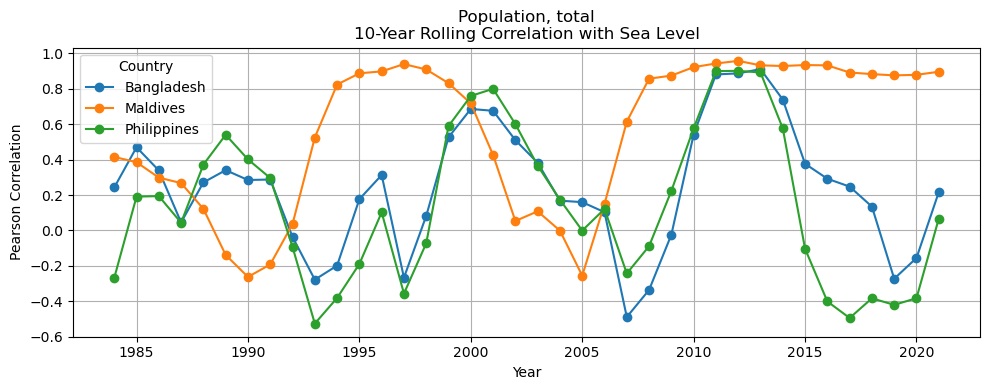

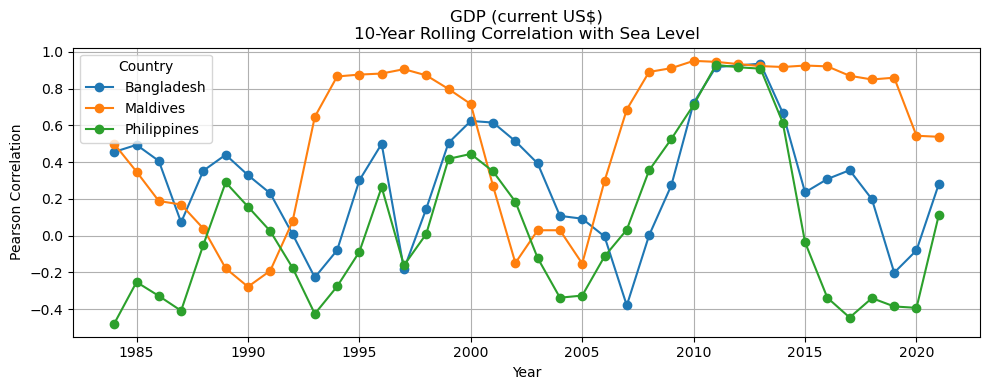

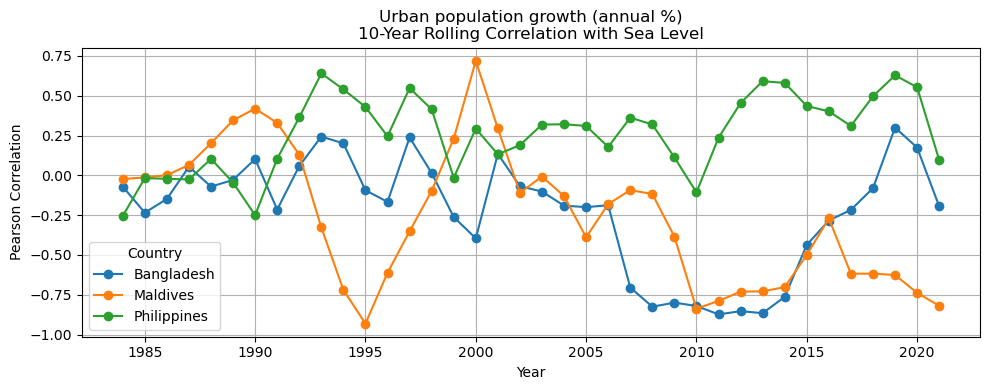

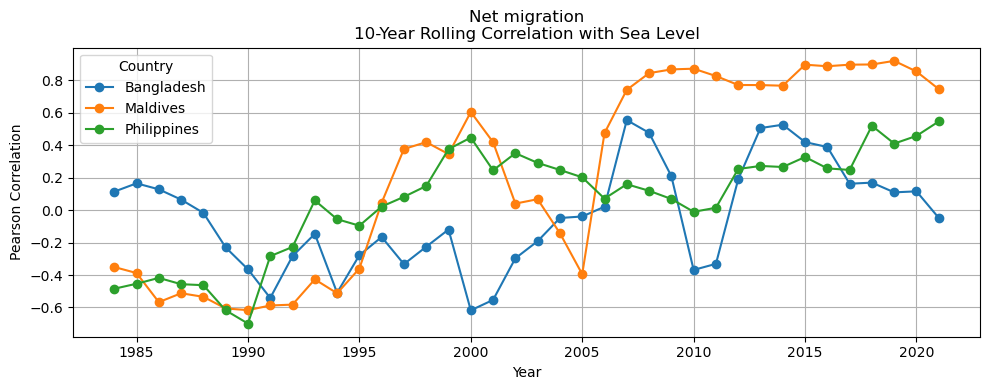

In [ ]:

df = pd.read_csv("full_country_stats_with_sea_level.csv")

indicators = [
    "Population, total",
    "GDP (current US$)",
    "Urban population growth (annual %)",
    "Net migration"
]

countries = ["Bangladesh", "Maldives", "Philippines"]


for indicator in indicators:
    plt.figure(figsize=(10, 4))
    for country in countries:
        # filter
        sub = df[df["Country Name"] == country].sort_values("Year")
        sea = sub["Sea Level (mm)"]
        ind = pd.to_numeric(sub[indicator], errors="coerce")
        
        # 10 year rolling
        rolling_corr = sea.rolling(window=10).corr(ind)
        
        plt.plot(sub["Year"], rolling_corr, marker='o', label=country)
    
    plt.title(f"{indicator}\n10-Year Rolling Correlation with Sea Level")
    plt.xlabel("Year")
    plt.ylabel("Pearson Correlation")
    plt.grid(True)
    plt.legend(title="Country")
    plt.tight_layout()
    plt.show()


* Population, total
  * Maldives: Consistently high positive correlation (≈0.8–0.95), indicating that population size and sea level rise in near lockstep.
  * Bangladesh & Philippines: Exhibit greater cyclical fluctuations—some decades show high correlation (≈0.7–0.9), while others drop to near zero or even negative values, reflecting the influence of coastal migration, urbanization, and major climate events on synchronization.

* GDP (current US$)
  * Maldives: Maintains a strong positive correlation, suggesting long-term alignment between economic growth and sea level rise.
  * Bangladesh & Philippines: Correlation fluctuates across decades—peaking at 0.6–0.8 in some periods but weakening significantly in others, likely due to economic crises, reforms, or industrial shifts.

* Urban population growth (annual %)
  * Bangladesh & Philippines: Correlation rises (e.g., 0.6–0.8 during rapid urbanization decades like the 2000s), indicating tighter coupling between urban expansion and sea level rise.
  * Maldives: Minimal fluctuations in urbanization rates sustain high correlation (>0.7), as both population and urban growth remain closely tied to sea level changes.

* Net migration
  * All three countries display noisier correlations:
  * Some decades show positive correlation (increased migration driven by sea level rise).
  * Others show negative correlation (higher migration rates despite stable sea levels), reflecting the complex interplay of economic, policy, and environmental drivers.


# Flood Correlation with Socioeconomic

In [30]:
import pandas as pd

# 1. Load flood data
def load_flood(path, country):
    df = pd.read_excel(path, sheet_name="Recent-Flooding")
    df['Country'] = country
    return (
        df.melt(
            id_vars=['Country','Year'],
            value_vars=[
                'High Tide Flood Days Minor',
                'High Tide Flood Days Moderate',
                'High Tide Flood Days Major'
            ],
            var_name='FloodType',
            value_name='FloodDays'
        )
        .dropna(subset=['FloodDays','Year'])
    )

bang = load_flood("data/bangladesh_sea_level.xlsx",  "Bangladesh")
mal = load_flood("data/maldives_sea_level.xlsx",    "Maldives")
phi = load_flood("data/philippines_sea_level.xlsx", "Philippines")
flood_df = pd.concat([bang, mal, phi], ignore_index=True)

# 2. Load socio‐economic panel data
stats = pd.read_csv("full_country_stats_with_sea_level.csv")
stats = stats.rename(columns={"Country Name":"Country"})

# 3. Merge and melt indicators
indicators = [
    "Population, total",
    "GDP (current US$)",
    "Urban population growth (annual %)",
    "Net migration"
]
merged = pd.merge(
    flood_df,
    stats[['Country','Year'] + indicators],
    on=['Country','Year'],
    how='inner'
)
# long form for indicators
df_long = (
    merged
    .melt(
        id_vars=['Country','Year','FloodType','FloodDays'],
        value_vars=indicators,
        var_name='Indicator',
        value_name='IndicatorValue'
    )
    .dropna(subset=['IndicatorValue'])
)

# 4. Compute correlation table
records = []
for country in df_long['Country'].unique():
    for ftype in df_long['FloodType'].unique():
        sub = df_long[(df_long['Country']==country)&(df_long['FloodType']==ftype)]
        for ind in indicators:
            corr = sub.loc[sub['Indicator']==ind, ['FloodDays','IndicatorValue']].corr().iloc[0,1]
            records.append({
                'Country': country,
                'FloodType': ftype,
                'Indicator': ind,
                'PearsonCorr': corr
            })

corr_df = pd.DataFrame(records)
corr_df



,Country,FloodType,Indicator,PearsonCorr
0,Bangladesh,High Tide Flood Days Minor,"Population, total",0.772470
1,Bangladesh,High Tide Flood Days Minor,GDP (current US$),0.670853
2,Bangladesh,High Tide Flood Days Minor,Urban population growth (annual %),-0.453464
3,Bangladesh,High Tide Flood Days Minor,Net migration,-0.792875
4,Bangladesh,High Tide Flood Days Moderate,"Population, total",0.710965
5,Bangladesh,High Tide Flood Days Moderate,GDP (current US$),0.614346
6,Bangladesh,High Tide Flood Days Moderate,Urban population growth (annual %),-0.383359
7,Bangladesh,High Tide Flood Days Moderate,Net migration,-0.774992
8,Bangladesh,High Tide Flood Days Major,"Population, total",0.682697
9,Bangladesh,High Tide Flood Days Major,GDP (current US$),0.629314


In [33]:
import pandas as pd
import altair as alt

# Enable consistent theme
alt.themes.enable('vox')

# 1. Load flood data for each country
def load_flood(path, country):
    df = pd.read_excel(path, sheet_name="Recent-Flooding")
    df['Country'] = country
    return df.melt(
        id_vars=['Country', 'Year'],
        value_vars=[
            'High Tide Flood Days Minor',
            'High Tide Flood Days Moderate',
            'High Tide Flood Days Major'
        ],
        var_name='FloodType',
        value_name='FloodDays'
    ).dropna(subset=['FloodDays', 'Year'])

bang = load_flood("data/bangladesh_sea_level.xlsx", "Bangladesh")
mal = load_flood("data/maldives_sea_level.xlsx", "Maldives")
phi = load_flood("data/philippines_sea_level.xlsx", "Philippines")
flood_df = pd.concat([bang, mal, phi], ignore_index=True)

# 2. Load socio-economic panel data
stats = pd.read_csv("full_country_stats_with_sea_level.csv")
stats = stats.rename(columns={"Country Name": "Country"})

# 3. Merge flood days with socio-economic indicators
indicators = [
    "Population, total",
    "GDP (current US$)",
    "Urban population growth (annual %)",
    "Net migration"
]
merged = pd.merge(
    flood_df,
    stats[['Country', 'Year'] + indicators],
    on=['Country', 'Year'],
    how='inner'
)

# 4. Melt socio-economic indicators into long format
melt_df = merged.melt(
    id_vars=['Country', 'Year', 'FloodType', 'FloodDays'],
    value_vars=indicators,
    var_name='Indicator',
    value_name='IndicatorValue'
).dropna(subset=['IndicatorValue'])

# 5. Define selection controls
countries = melt_df['Country'].unique().tolist()
flood_types = melt_df['FloodType'].unique().tolist()

country_sel = alt.selection_point(
    name='CountrySel',
    fields=['Country'],
    bind=alt.binding_radio(options=countries, name='Country: '),
    value=[{'Country': countries[0]}],
    empty='none'
)

type_sel = alt.selection_point(
    name='TypeSel',
    fields=['FloodType'],
    bind=alt.binding_radio(options=flood_types, name='Flood Type: '),
    value=[{'FloodType': flood_types[0]}],
    empty='none'
)

# 6. Base chart filtered by selections
base = alt.Chart(melt_df) \
    .transform_filter(country_sel) \
    .transform_filter(type_sel)

# 7. Faceted scatter: one column per indicator
chart = base.mark_circle(size=60) \
    .encode(
        x=alt.X('IndicatorValue:Q', title='Value'),
        y=alt.Y('FloodDays:Q', title='High Tide Flood Days'),
        tooltip=[
            alt.Tooltip('Country:N', title='Country'),
            alt.Tooltip('FloodType:N', title='Flood Type'),
            alt.Tooltip('Year:O', title='Year'),
            alt.Tooltip('Indicator:N', title='Indicator'),
            alt.Tooltip('IndicatorValue:Q', title='Value', format=',.2f'),
            alt.Tooltip('FloodDays:Q', title='Days')
        ]
    ) \
    .properties(width=250, height=250) \
    .facet(
        column=alt.Column('Indicator:N', title=None, header=alt.Header(labelFontSize=12))
    )

# 8. Combine with selections, independent X, shared Y
final_chart = chart.add_params(country_sel, type_sel) \
    .resolve_scale(x='independent', y='shared')

final_chart


/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/vegalite/v5/api.py:362: AltairDeprecationWarning: The value of 'empty' should be True or False.
  warnings.warn(
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/Users/jeff/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.as

alt.FacetChart(...)

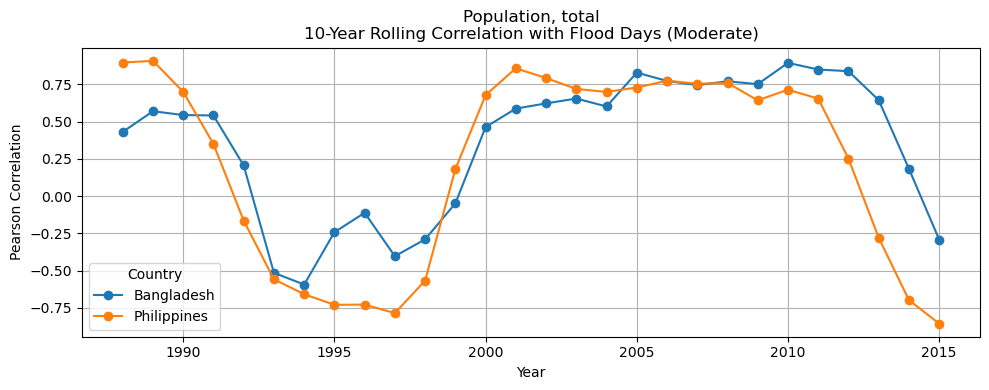

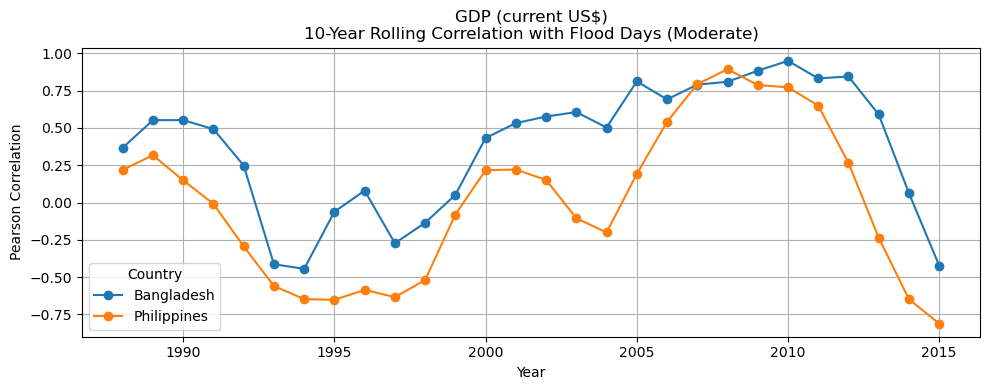

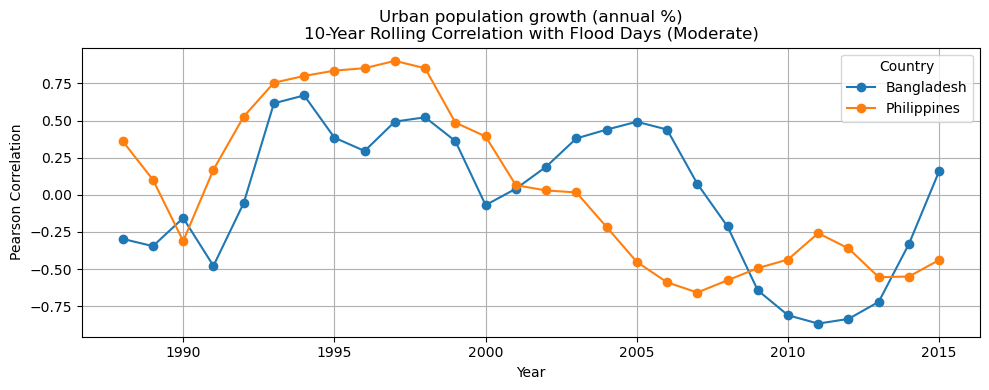

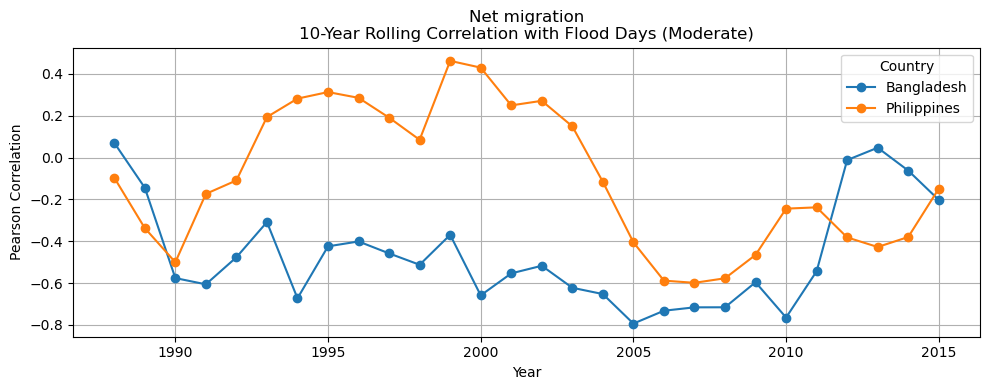

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load socio-economic panel data
stats = pd.read_csv("full_country_stats_with_sea_level.csv")
stats = stats.rename(columns={"Country Name": "Country"})

# 2. Load moderate flood days for each country
def load_moderate_flood(path, country):
    df = pd.read_excel(path, sheet_name="Recent-Flooding")
    return df[['Year', 'High Tide Flood Days Moderate']].rename(
        columns={'High Tide Flood Days Moderate': 'FloodDays'}
    ).assign(Country=country).dropna()

bang = load_moderate_flood("data/bangladesh_sea_level.xlsx", "Bangladesh")
mal = load_moderate_flood("data/maldives_sea_level.xlsx",    "Maldives")
phi = load_moderate_flood("data/philippines_sea_level.xlsx", "Philippines")
flood_df = pd.concat([bang, mal, phi], ignore_index=True)

# 3. Merge flood days with socio-economic indicators
indicators = [
    "Population, total",
    "GDP (current US$)",
    "Urban population growth (annual %)",
    "Net migration"
]
merged = pd.merge(
    flood_df,
    stats[['Country', 'Year'] + indicators],
    on=['Country', 'Year'],
    how='inner'
)

# 4. Plot 10-year rolling correlation for each indicator
countries = ["Bangladesh", "Philippines"]

for indicator in indicators:
    plt.figure(figsize=(10, 4))
    for country in countries:
        sub = merged[merged['Country'] == country].sort_values("Year")
        sea = sub['FloodDays']
        ind = pd.to_numeric(sub[indicator], errors='coerce')
        
        # Compute 10-year rolling Pearson correlation
        rolling_corr = sea.rolling(window=10).corr(ind)
        
        plt.plot(sub['Year'], rolling_corr, marker='o', label=country)
    
    plt.title(f"{indicator}\n10-Year Rolling Correlation with Flood Days (Moderate)")
    plt.xlabel("Year")
    plt.ylabel("Pearson Correlation")
    plt.grid(True)
    plt.legend(title="Country")
    plt.tight_layout()
    plt.show()


# Precipitation Correlation with Socioeconomic

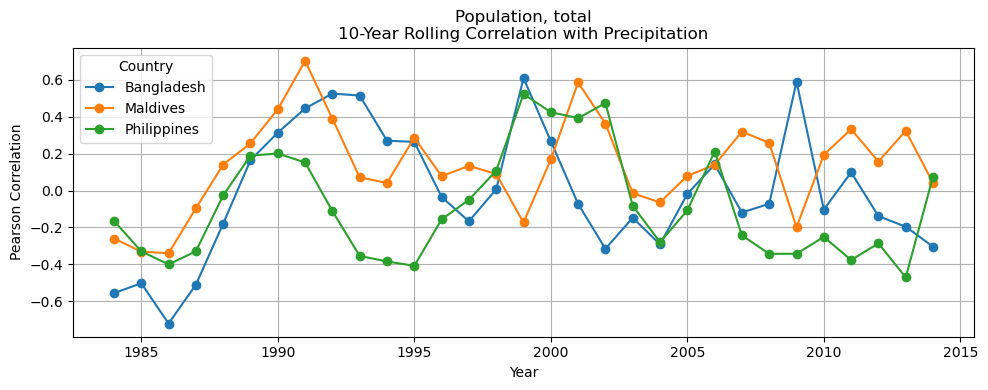

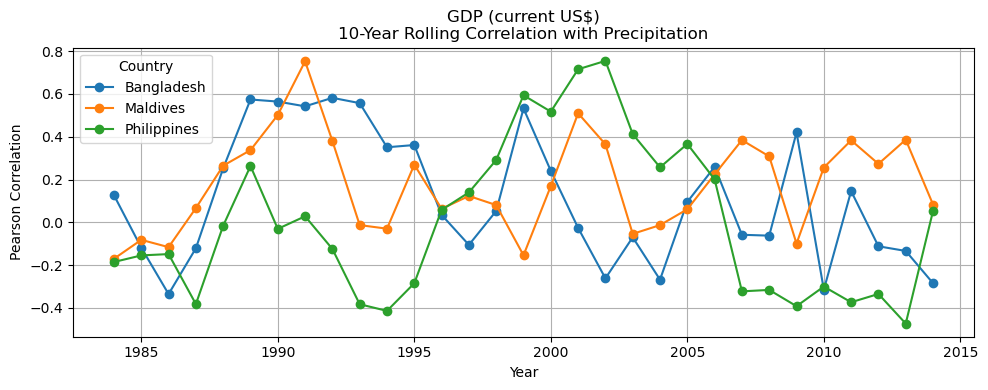

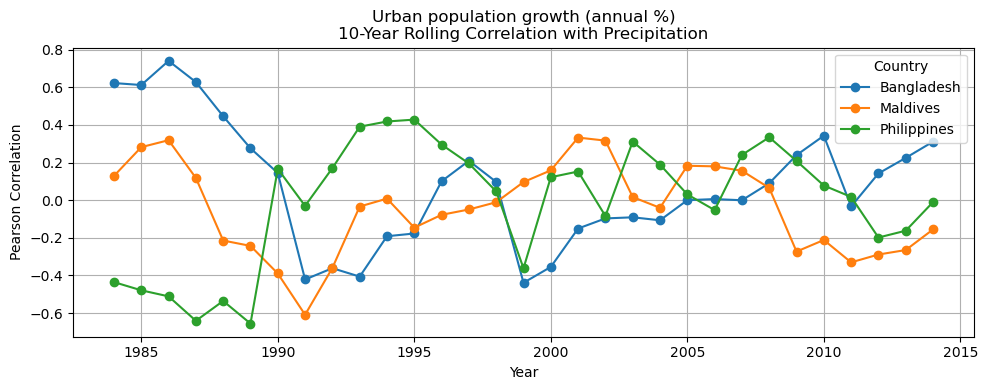

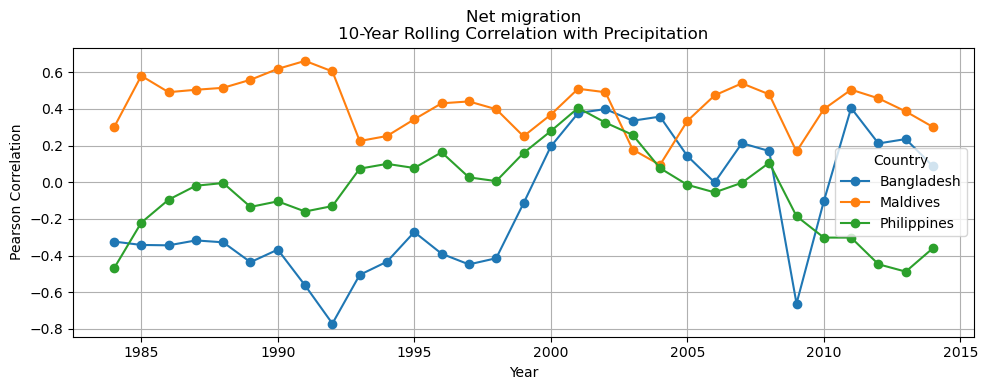

In [67]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load socio‐economic panel data
stats = pd.read_csv("full_country_stats_with_sea_level.csv")
stats = stats.rename(columns={"Country Name": "Country"})

# 2. Load annual precipitation data
file_path = "cmip6-x0.25_timeseries_pr,tas_timeseries_annual_1950-2014_median_historical_ensemble_all_mean.xlsx"
xl = pd.ExcelFile(file_path)
pr = (
    xl.parse("pr")
      .drop(columns=["code"])
      .rename(columns={"name": "Country"})
)
pr_long = (
    pr.melt(id_vars=["Country"], var_name="Year", value_name="Precipitation")
      .dropna(subset=["Precipitation"])
)
pr_long["Year"] = pr_long["Year"].str.extract(r"(\d{4})").astype(int)
pr_long["Precipitation"] = pd.to_numeric(pr_long["Precipitation"], errors="coerce")

# 3. Merge precipitation with socio‐economic indicators
indicators = [
    "Population, total",
    "GDP (current US$)",
    "Urban population growth (annual %)",
    "Net migration"
]
merged = pd.merge(
    pr_long,
    stats[["Country", "Year"] + indicators],
    on=["Country", "Year"],
    how="inner"
)

# 4. Plot 10-year rolling correlation for each indicator, including Maldives
countries = ["Bangladesh", "Maldives", "Philippines"]

for indicator in indicators:
    plt.figure(figsize=(10, 4))
    for country in countries:
        sub = merged[merged["Country"] == country].sort_values("Year")
        precip = sub["Precipitation"]
        ind_series = pd.to_numeric(sub[indicator], errors="coerce")
        
        # Compute 10-year rolling Pearson correlation
        rolling_corr = precip.rolling(window=10).corr(ind_series)
        
        plt.plot(sub["Year"], rolling_corr, marker='o', label=country)
    
    plt.title(f"{indicator}\n10-Year Rolling Correlation with Precipitation")
    plt.xlabel("Year")
    plt.ylabel("Pearson Correlation")
    plt.grid(True)
    plt.legend(title="Country")
    plt.tight_layout()
    plt.show()


# Precipitation > 50(mm) Correlation with Socioeconomic

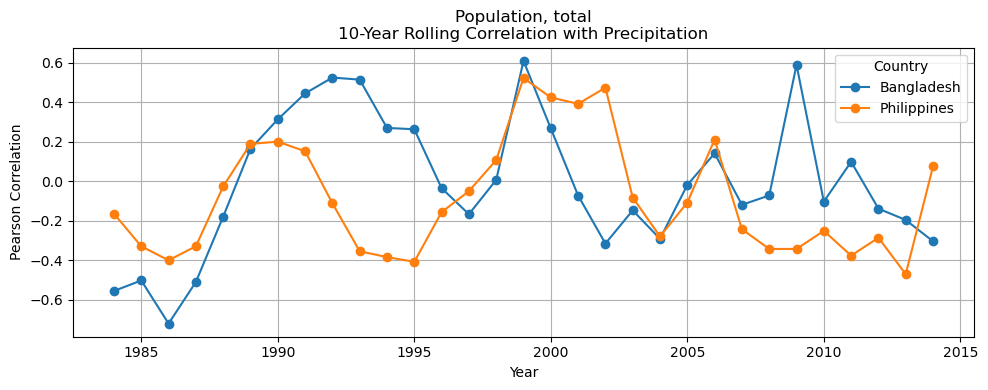

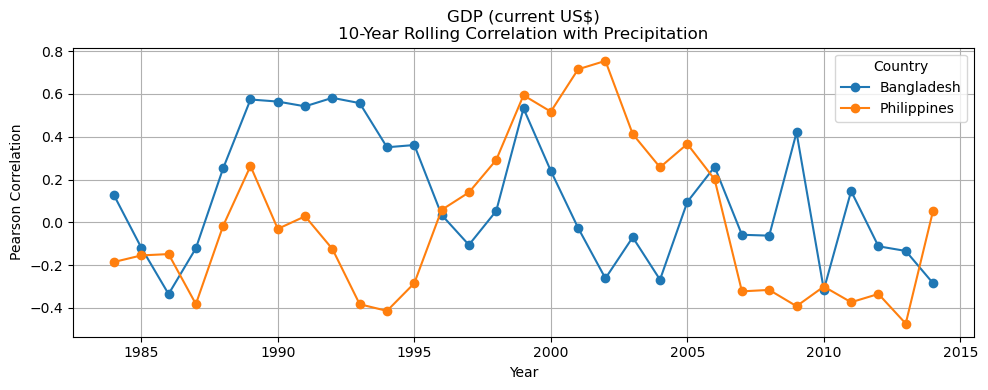

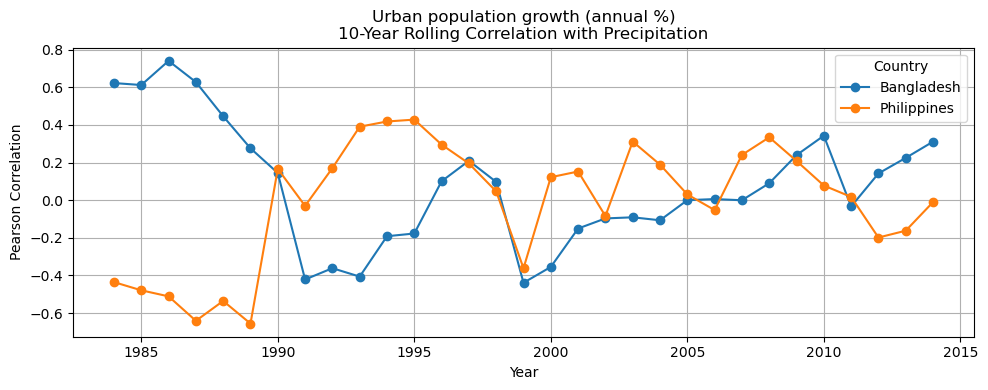

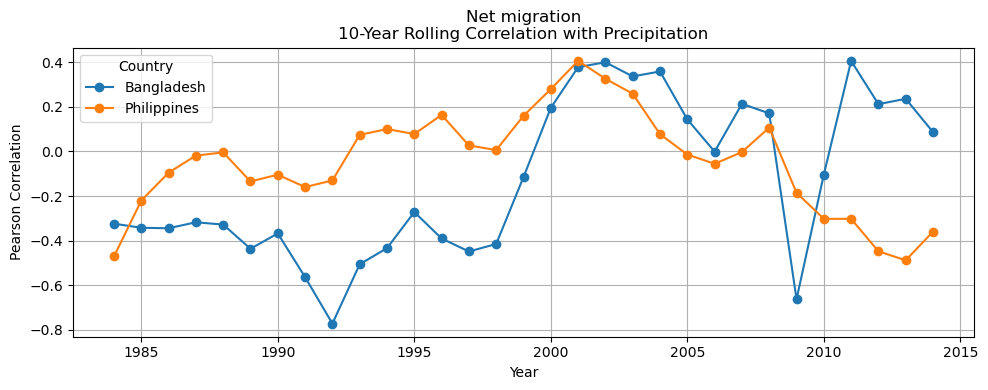

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load socio-economic panel data
stats = pd.read_csv("full_country_stats_with_sea_level.csv")
stats = stats.rename(columns={"Country Name": "Country"})

# 2. Load annual precipitation data
file_path = "cmip6-x0.25_timeseries_pr,tas_timeseries_annual_1950-2014_median_historical_ensemble_all_mean.xlsx"
xl = pd.ExcelFile(file_path)
pr = (
    xl.parse("pr")
      .drop(columns=["code"])
      .rename(columns={"name": "Country"})
)
pr_long = (
    pr.melt(id_vars=["Country"], var_name="Year", value_name="Precipitation")
      .dropna(subset=["Precipitation"])
)
pr_long["Year"] = pr_long["Year"].str.extract(r"(\d{4})").astype(int)
pr_long["Precipitation"] = pd.to_numeric(pr_long["Precipitation"], errors="coerce")

# 3. Merge precipitation with socio-economic indicators
indicators = [
    "Population, total",
    "GDP (current US$)",
    "Urban population growth (annual %)",
    "Net migration"
]
merged = pd.merge(
    pr_long,
    stats[["Country", "Year"] + indicators],
    on=["Country", "Year"],
    how="inner"
)

# 4. Plot 10-year rolling correlation for each indicator, excluding Maldives
countries = ["Bangladesh", "Philippines"]

for indicator in indicators:
    plt.figure(figsize=(10, 4))
    for country in countries:
        sub = merged[merged["Country"] == country].sort_values("Year")
        precip = sub["Precipitation"]
        ind_series = pd.to_numeric(sub[indicator], errors="coerce")
        
        # Compute 10-year rolling Pearson correlation
        rolling_corr = precip.rolling(window=10).corr(ind_series)
        
        plt.plot(sub["Year"], rolling_corr, marker='o', label=country)
    
    plt.title(f"{indicator}\n10-Year Rolling Correlation with Precipitation")
    plt.xlabel("Year")
    plt.ylabel("Pearson Correlation")
    plt.grid(True)
    plt.legend(title="Country")
    plt.tight_layout()
    plt.show()


# Vulnerability Index

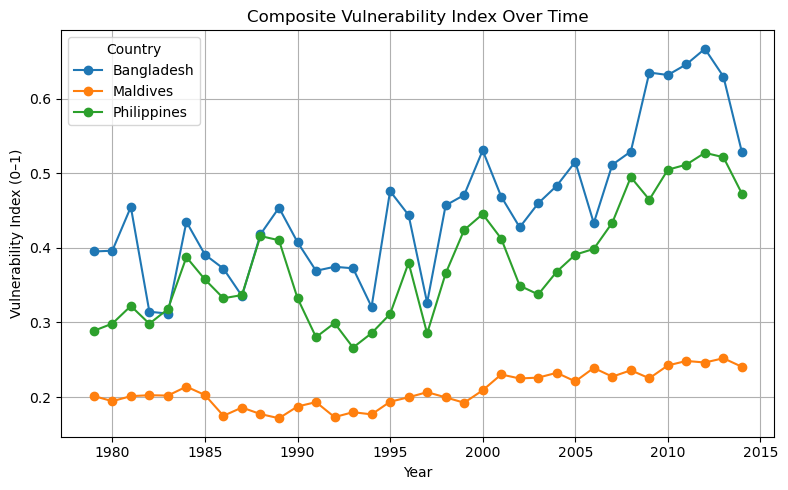

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


stats = pd.read_csv("data/full_country_stats_with_sea_level.csv")
stats = stats.rename(columns={"Country Name": "Country"})


xl_pr = pd.ExcelFile("data/cmip6-x0.25_timeseries_pr,tas_timeseries_annual_1950-2014_median_historical_ensemble_all_mean.xlsx")
pr = xl_pr.parse("pr").drop(columns=["code"]).rename(columns={"name": "Country"})
pr_long = (
    pr.melt(id_vars=["Country"], var_name="Year", value_name="Precipitation")
      .dropna(subset=["Preipitation"])
)
pr_long["Year"] = pr_long["Year"].str.extract(r"(\d{4})").astype(int)
pr_long["Precipitation"] = pd.to_numeric(pr_long["Precipitation"], errors="coerce")


def load_moderate(path, country):
    df = pd.read_excel(path, sheet_name="Recent-Flooding")
    df["Country"] = country
    df = df[[
        "Country",
        "Year",
        "High Tide Flood Days Moderate",
        "High Tide Flood Days Major",
        "High Tide Flood Days Minor"
    ]].rename(columns={
        "High Tide Flood Days Moderate": "Moderate",
        "High Tide Flood Days Major":    "Major",
        "High Tide Flood Days Minor":    "Minor"
    })

    df = df.dropna(subset=["Moderate", "Major", "Minor", "Year"], how="all")
    return df

bang = load_moderate("data/bangladesh_sea_level.xlsx",  "Bangladesh")
mal  = load_moderate("data/maldives_sea_level.xlsx",    "Maldives")
phi  = load_moderate("data/philippines_sea_level.xlsx", "Philippines")
flood_df = pd.concat([bang, mal, phi], ignore_index=True)


df = (
    stats
    .merge(pr_long, on=["Country","Year"], how="inner")
    .merge(flood_df, on=["Country","Year"], how="inner")
)


features = [
    "Precipitation",
    "Major",
    "Moderate",
    "Minor",
    "Sea Level (mm)",
    "Population, total",
    "GDP (current US$)",
    "Urban population growth (annual %)",
    "Net migration"
]

df_features = df[["Country","Year"] + features].dropna()


df_time = df_features.copy()
for feat in features:
    mn, mx = df_time[feat].min(), df_time[feat].max()
    df_time[feat + "_norm"] = (df_time[feat] - mn) / (mx - mn)

norm_cols = [f + "_norm" for f in features]
df_time["VulnerabilityIndex"] = df_time[norm_cols].mean(axis=1)


plt.figure(figsize=(8,5))
for country in df_time["Country"].unique():
    sub = df_time[df_time["Country"] == country]
    plt.plot(sub["Year"], sub["VulnerabilityIndex"], marker='o', label=country)
plt.xlabel("Year")
plt.ylabel("Vulnerability Index (0–1)")
plt.title("Composite Vulnerability Index Over Time")
plt.legend(title="Country")
plt.grid(True)
plt.tight_layout()
plt.show()



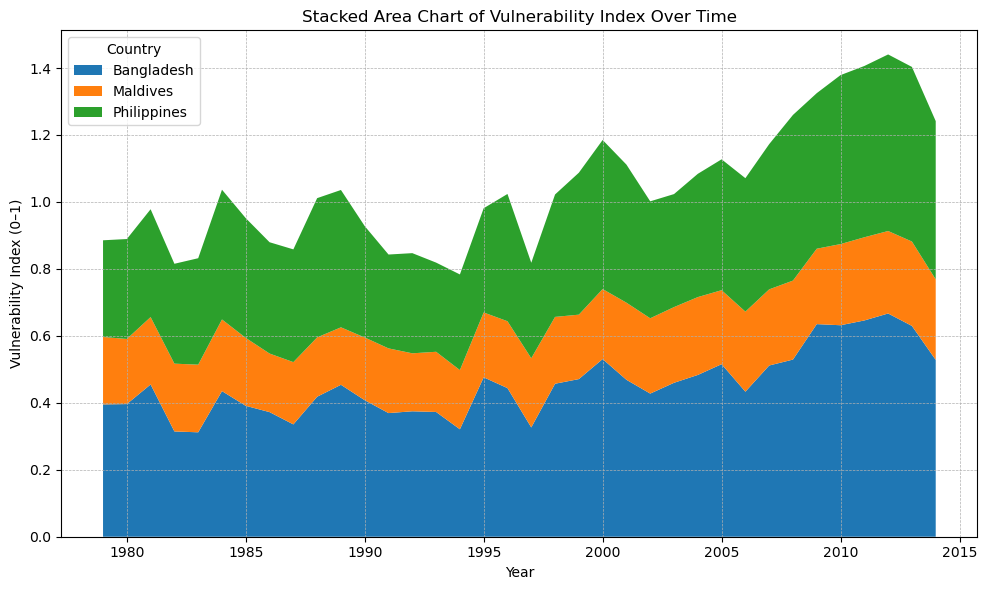

In [100]:
df_pivot = df_time.pivot(index='Year',
                         columns='Country',
                         values='VulnerabilityIndex')

# Create the stacked area chart
plt.figure(figsize=(10, 6))
plt.stackplot(df_pivot.index,         # x values (Year)
              df_pivot.T.values,      # y values (one series per country)
              labels=df_pivot.columns)  # legend labels

plt.xlabel('Year')
plt.ylabel('Vulnerability Index (0–1)')
plt.title('Stacked Area Chart of Vulnerability Index Over Time')
plt.legend(title='Country', loc='upper left')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

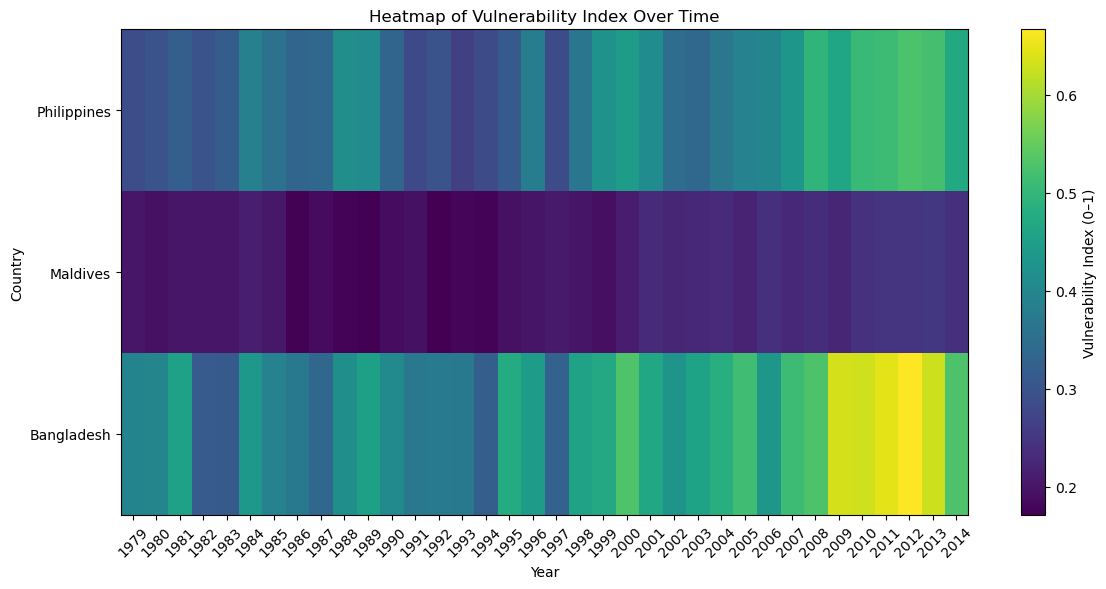

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# Pivot so rows are years, columns are countries
heat = df_time.pivot(index='Year', columns='Country', values='VulnerabilityIndex')

plt.figure(figsize=(12, 6))
plt.imshow(heat.T,               # transpose so countries are on y-axis
           aspect='auto',        # stretch to fill axes
           origin='lower',       # year increasing upward
           cmap='viridis')       # default matplotlib colormap
plt.colorbar(label='Vulnerability Index (0–1)')
plt.xticks(np.arange(len(heat.index)), heat.index, rotation=45)
plt.yticks(np.arange(len(heat.columns)), heat.columns)
plt.xlabel('Year')
plt.ylabel('Country')
plt.title('Heatmap of Vulnerability Index Over Time')
plt.tight_layout()
plt.show()


# Pearson correlation at shifted time from –5 to +5 years

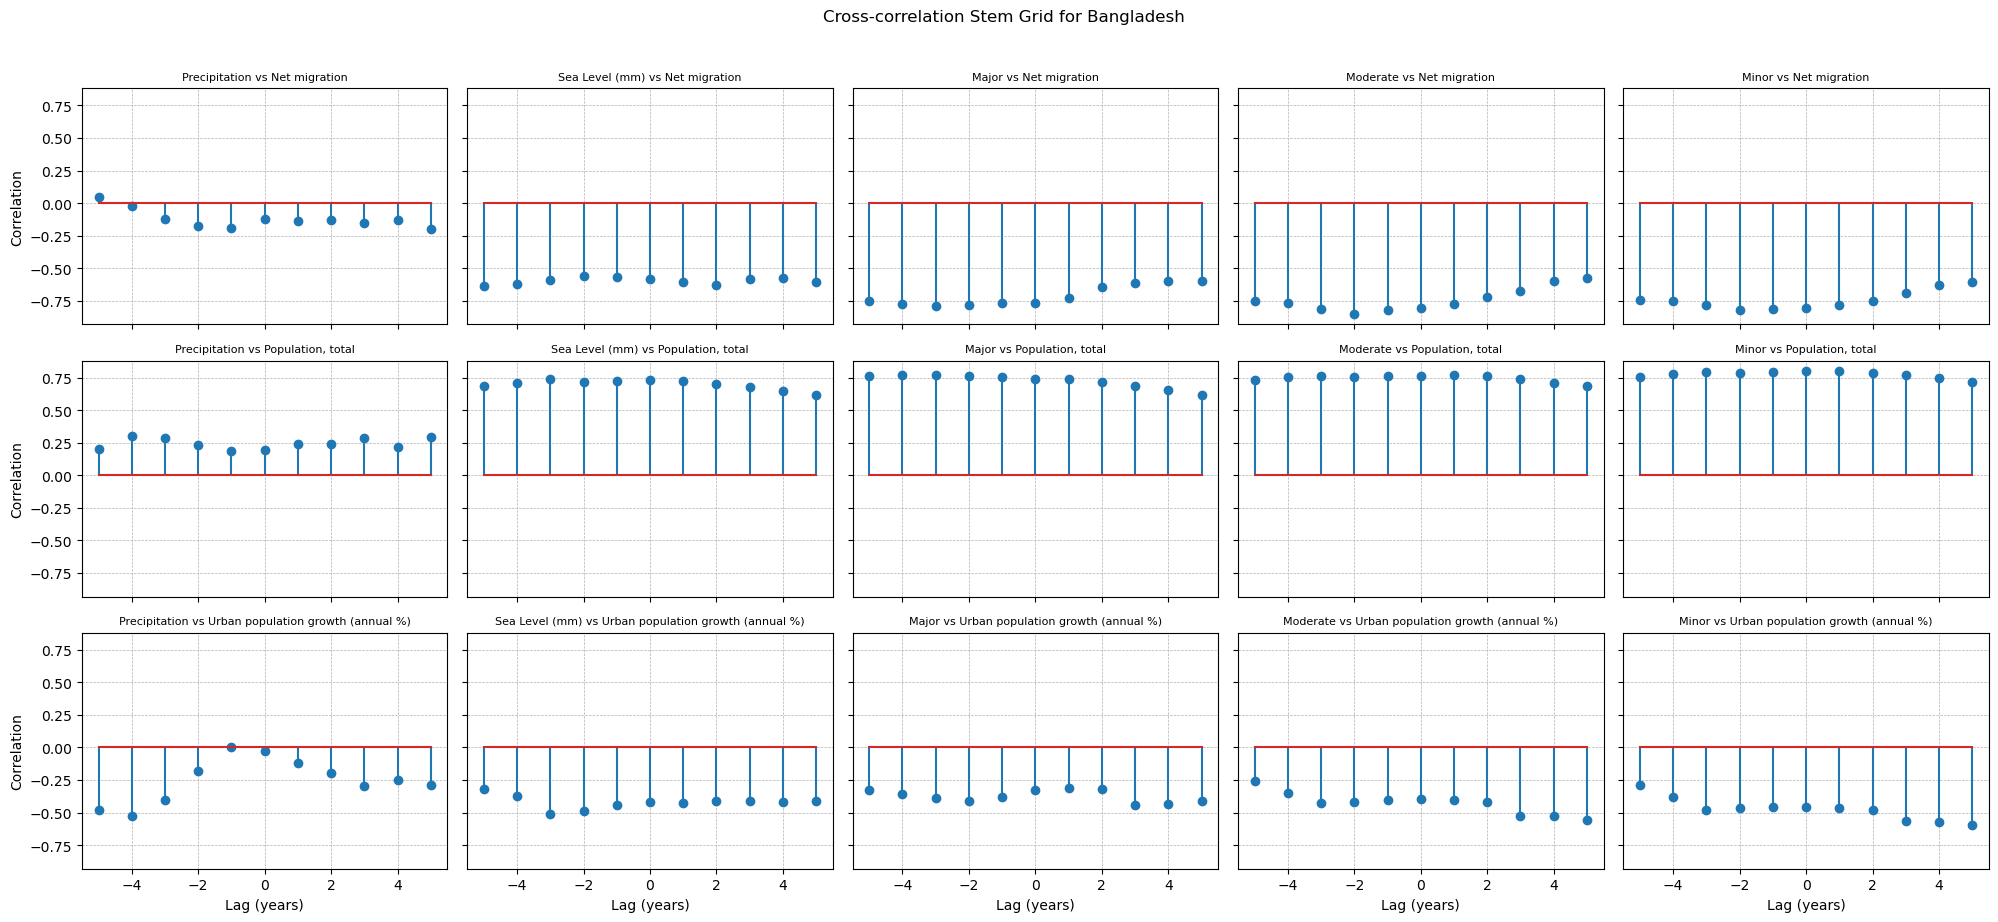

/Users/jeff/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/Users/jeff/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide



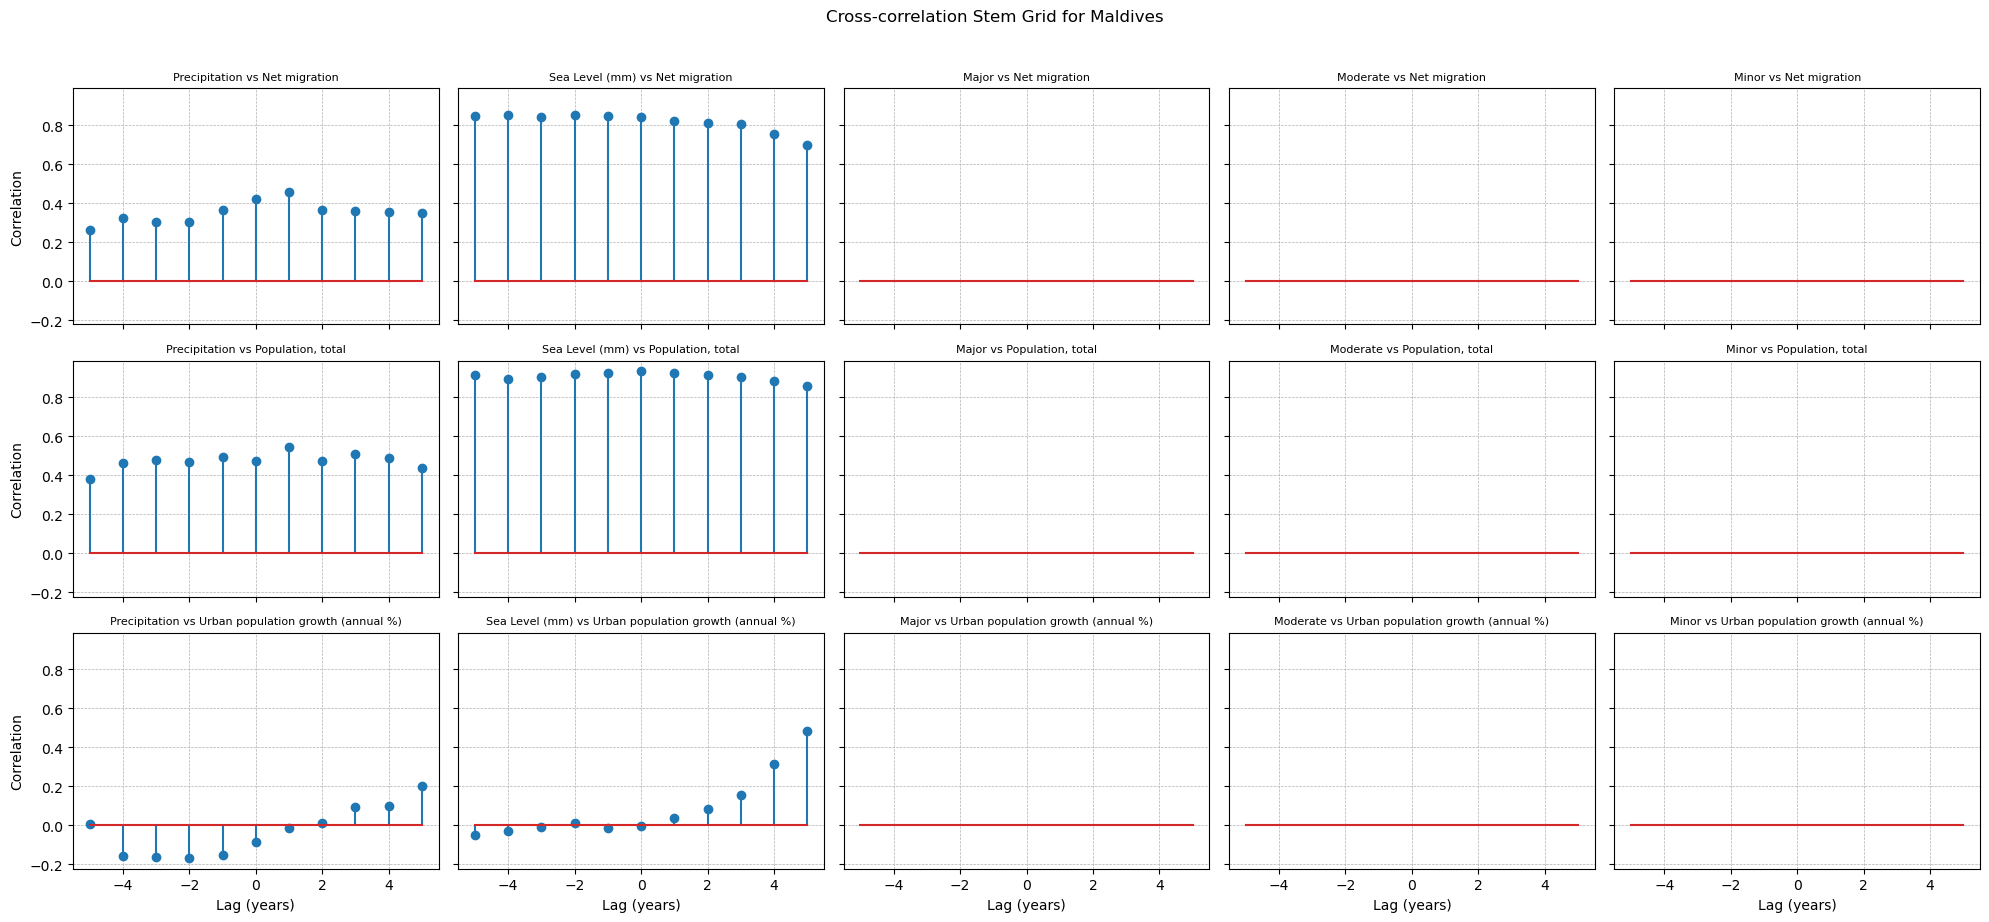

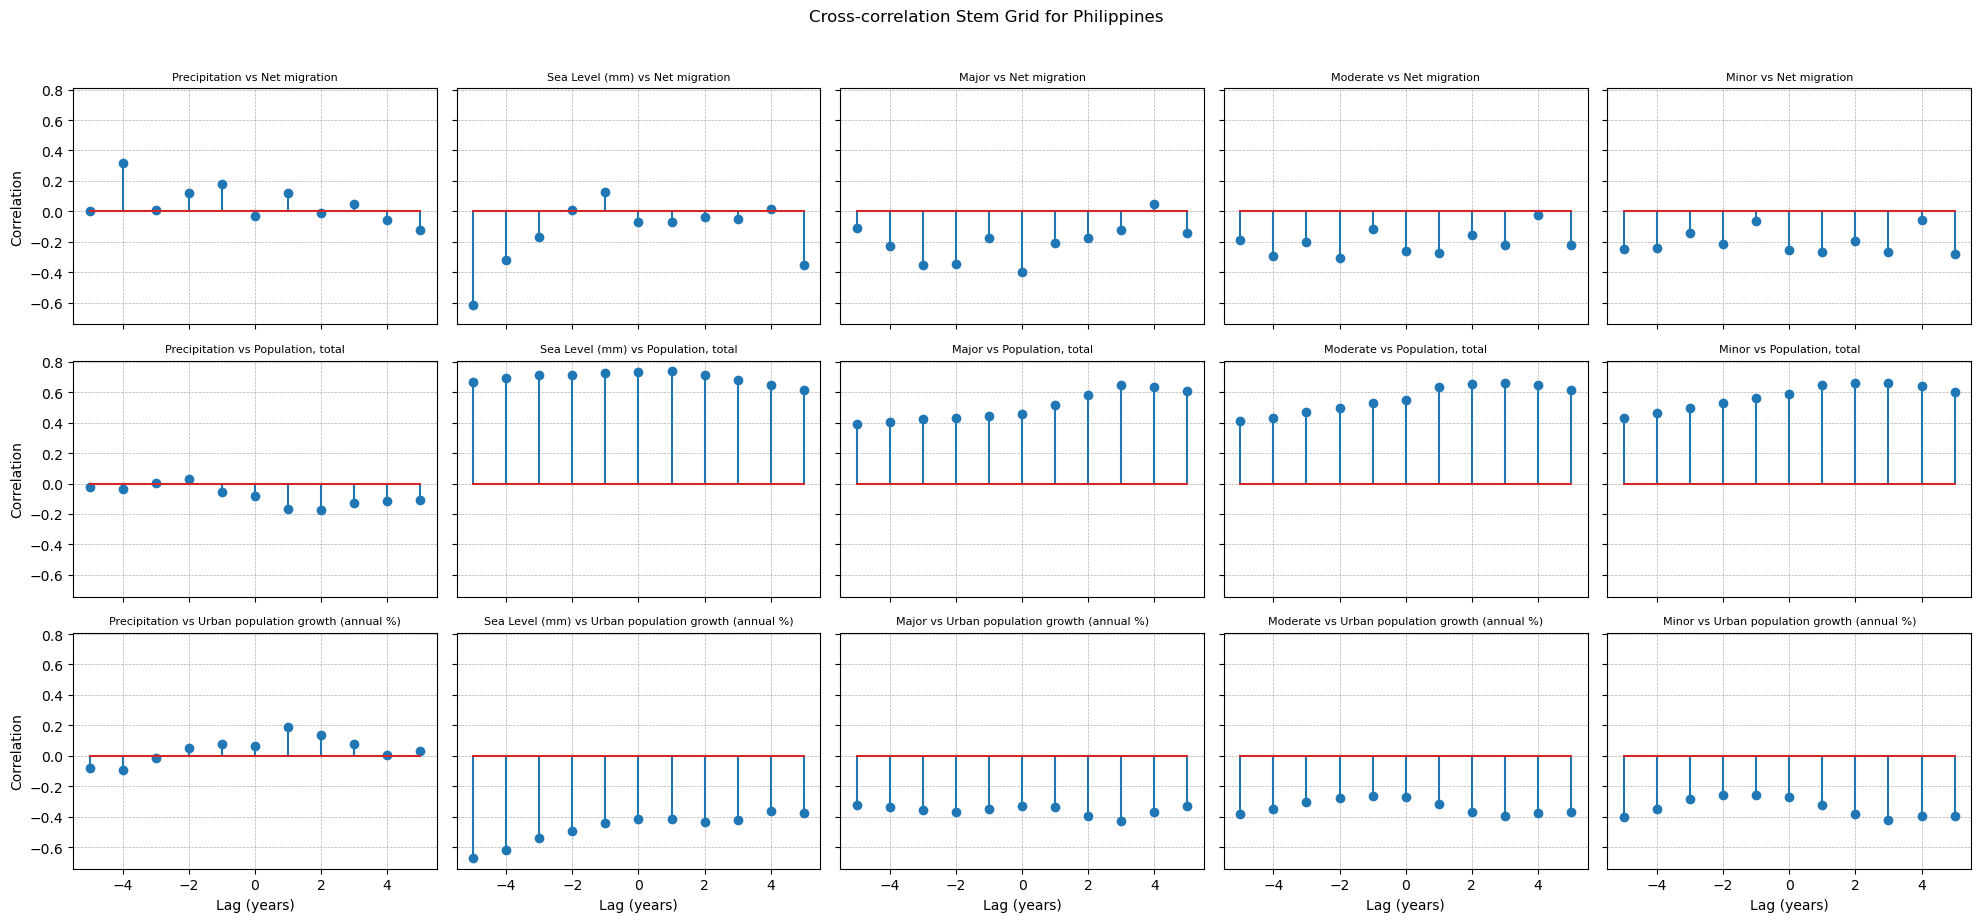

In [122]:
import numpy as np
import matplotlib.pyplot as plt

# Define which climate and social variables to compare
climate_vars = [
    'Precipitation',
    'Sea Level (mm)',
    'Major',
    'Moderate',
    'Minor'
]
social_vars = [
    'Net migration',
    'Population, total',
    'Urban population growth (annual %)'
]
max_lag = 5  # number of years to lag forward and backward

# Loop over each country
for country in df_time['Country'].unique():
    # Subset and index by Year
    ts = (
        df_time[df_time['Country'] == country]
        .set_index('Year')
        .sort_index()
    )

    # Prepare a grid of subplots: rows = social_vars, cols = climate_vars
    nrows, ncols = len(social_vars), len(climate_vars)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4 * ncols, 3 * nrows),
        sharex=True,
        sharey=True
    )

    # Fill each subplot with a stem plot of cross‐correlation vs. lag
    for i, social_var in enumerate(social_vars):
        for j, climate_var in enumerate(climate_vars):
            lags = np.arange(-max_lag, max_lag + 1)
            ccf_vals = [
                ts[climate_var].corr(ts[social_var].shift(-lag))
                for lag in lags
            ]

            ax = axes[i, j]
            ax.stem(lags, ccf_vals)

            # Label only the bottom row and left column
            if i == nrows - 1:
                ax.set_xlabel('Lag (years)')
            if j == 0:
                ax.set_ylabel('Correlation')

            ax.set_title(f'{climate_var} vs {social_var}', fontsize=8)
            ax.grid(True, linestyle='--', linewidth=0.5)

    # Add a super‐title and adjust layout
    fig.suptitle(f'Cross-correlation Stem Grid for {country}', y=1.02)
    plt.tight_layout()
    plt.show()


* Peak at lag = 0：
    A high stem at 0 means the two series co‐vary in the same year.
* Peak at positive lag
    Suggests that fluctuations in the climate variable tend to be followed by changes in the social indicator after that many years.
    E.g. a big positive spike at lag = +1 for (Major flood days) → (Net migration) would imply that heavy flooding in year t tends to push migration up in year _t + 1.
* Peak at negative lag
    Less intuitive for climate→social, but could point to pre‐conditioning or data quirks—e.g. a social trend that reliably precedes a measured climate anomaly (or artifacts of smoothing, indexing, etc.).

By scanning across the grid, you can see which climate stressors have the strongest contemporaneous (lag = 0) or delayed (lag > 0) impacts on each social outcome, and compare relative timings (flood days vs. sea-level vs. precipitation).
these plots help you identify not just whether a climate stressor correlates with a social outcome, but also when that effect is strongest—offering clues about the temporal dynamics of climate-driven social change.

In [167]:
import pandas as pd
import numpy as np
import altair as alt
from scipy.stats import pearsonr

# 1. Define variables and lag range
climate_vars = [
    'Precipitation',
    'Sea Level (mm)',
    'Major',
    'Moderate',
    'Minor'
]
social_vars = [
    'Net migration',
    'Population, total',
    'Urban population growth (annual %)'
]
lag_range = list(range(-10, 11))

# 2. Compute Pearson correlations for every (Country, Lag, Social, Feature)
records = []
for country in df_time['Country'].unique():
    ts = df_time[df_time['Country'] == country].set_index('Year').sort_index()
    for lag in lag_range:
        for social in social_vars:
            sub = ts.dropna(subset=climate_vars + [social])
            if len(sub) < 3:
                continue
            for feat in climate_vars:
                x = sub[feat]
                y = sub[social].shift(-lag)
                pair = pd.concat([x, y], axis=1).dropna()
                corr_value = pearsonr(pair.iloc[:, 0], pair.iloc[:, 1])[0] if len(pair) >= 2 else np.nan
                records.append({
                    'Country': country,
                    'Lag': lag,
                    'Social': social,
                    'Feature': feat,
                    'Correlation': corr_value
                })

df_corr = pd.DataFrame.from_records(records)

# 3. Create interactive parameters
first_country = sorted(df_corr['Country'].unique())[0]
country_param = alt.param(
    bind=alt.binding_select(options=sorted(df_corr['Country'].unique()), name='Country:'),
    name='country_param',
    value=first_country
)
lag_param = alt.param(
    bind=alt.binding_range(min=-10, max=10, step=1, name='Lag (years):'),
    name='lag_param',
    value=-10
)

# 4. Build the interactive faceted chart showing all features
chart = (
    alt.Chart(df_corr)
       .add_params(country_param, lag_param)
       .transform_filter(alt.datum.Country == country_param)
       .transform_filter(alt.datum.Lag == lag_param)
       .mark_bar()
       .encode(
           x=alt.X('Correlation:Q',
                   scale=alt.Scale(domain=[-1, 1]),
                   title='Pearson r (–1 to 1)'),
           y=alt.Y('Feature:N',
                   sort=climate_vars,
                   title='Climate Variable'),
           color=alt.Color('Feature:N', legend=None),
           tooltip=[
               alt.Tooltip('Feature:N'),
               alt.Tooltip('Correlation:Q', format=".2f")
           ]
       )
       .properties(
           width=400,
           height=300
       )
       .facet(column=alt.Column('Social:N', title=None))
       .resolve_scale(x='independent', y='shared')
)

chart


/Users/jeff/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/Users/jeff/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/Users/jeff/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/Users/jeff/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/Users/jeff/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

/Users/jeff/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning:

An in

alt.FacetChart(...)

count    756.000000
mean       0.039421
std        0.485327
min       -0.849388
25%       -0.385671
50%       -0.022459
75%        0.475827
max        0.933355
Name: Correlation, dtype: float64


In [ ]:


# 3. Identify the strongest absolute correlation per Country and Social
top_records = []
for country in df_corr['Country'].unique():
    for social in social_vars:
        subset = df_corr[
            (df_corr['Country'] == country) &
            (df_corr['Social'] == social)
        ].dropna(subset=['Correlation'])
        if subset.empty:
            continue
        idx = subset['Correlation'].abs().idxmax()
        top_records.append(subset.loc[idx])

df_top = pd.DataFrame(top_records).reset_index(drop=True)
df_top



,Country,Lag,Social,Feature,Correlation
0,Bangladesh,-2,Net migration,Moderate,-0.849388
1,Bangladesh,-10,"Population, total",Major,0.799469
2,Bangladesh,8,Urban population growth (annual %),Minor,-0.676188
3,Maldives,-4,Net migration,Sea Level (mm),0.854123
4,Maldives,0,"Population, total",Sea Level (mm),0.933355
5,Maldives,9,Urban population growth (annual %),Sea Level (mm),0.677512
6,Philippines,-5,Net migration,Sea Level (mm),-0.616847
7,Philippines,1,"Population, total",Sea Level (mm),0.738069
8,Philippines,-10,Urban population growth (annual %),Minor,-0.716279
